In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

In [34]:
def analyze_full_dataset(data_path='data'):
    splits = ['train', 'valid', 'test']
    bbox_list = []

    split_counts = {'train': {0: 0, 1: 0, 2: 0},
                    'valid': {0: 0, 1: 0, 2: 0},
                    'test': {0: 0, 1: 0, 2: 0}}
    total_counts = {0: 0, 1: 0, 2: 0}

    for split in splits:
        label_dir = os.path.join(data_path, split, 'labels')
        if not os.path.exists(label_dir):
            continue

        for label_file in os.listdir(label_dir):
            if not label_file.endswith('.txt'):
                continue

            with open(os.path.join(label_dir, label_file), 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls = int(parts[0])
                        width = float(parts[3])
                        height = float(parts[4])

                        split_counts[split][cls] += 1
                        total_counts[cls] += 1

                        bbox_list.append({
                            'Tập_dữ_liệu': split,
                            'Class': cls,
                            'Width': width,
                            'Height': height,
                            'Area': width * height,
                            'Aspect_Ratio': width / height
                        })

    return pd.DataFrame(bbox_list), total_counts, split_counts

In [35]:
df_bbox, counts, split_counts = analyze_full_dataset('data')
class_names_map = {0: 'Xe máy', 1: 'Có mũ', 2: 'Không mũ'}
names = [class_names_map[i] for i in range(3)]
total_values = [counts[i] for i in range(3)]

print(f"Đã gom xong dữ liệu! Tổng cộng: {len(df_bbox)} đối tượng.")

✅ Đã gom xong dữ liệu! Tổng cộng: 9584 đối tượng.


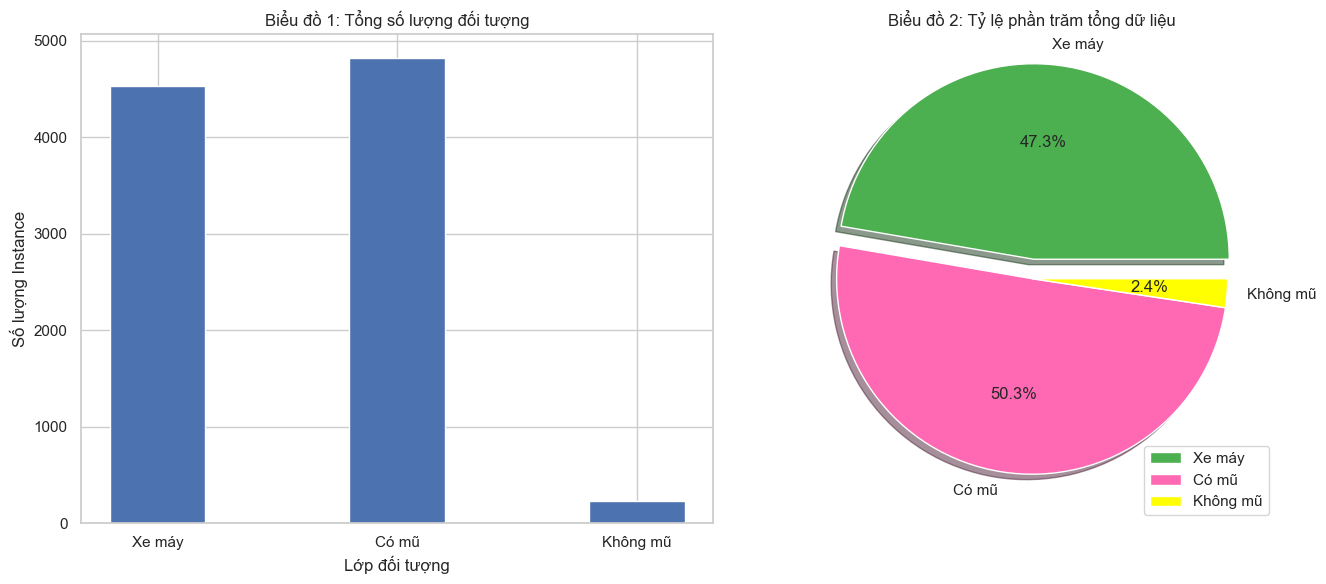

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(names, total_values, color='b', width=0.4)
axes[0].set_xlabel("Lớp đối tượng")
axes[0].set_ylabel("Số lượng Instance")
axes[0].set_title("Biểu đồ 1: Tổng số lượng đối tượng")

mausac = ["#4CAF50", "hotpink", "yellow"]
vitri = [0.1, 0, 0]
axes[1].pie(total_values, labels=names, colors=mausac, explode=vitri, shadow=True, autopct='%1.1f%%')
axes[1].set_title("Biểu đồ 2: Tỷ lệ phần trăm tổng dữ liệu")
axes[1].legend()

plt.tight_layout()
plt.show()

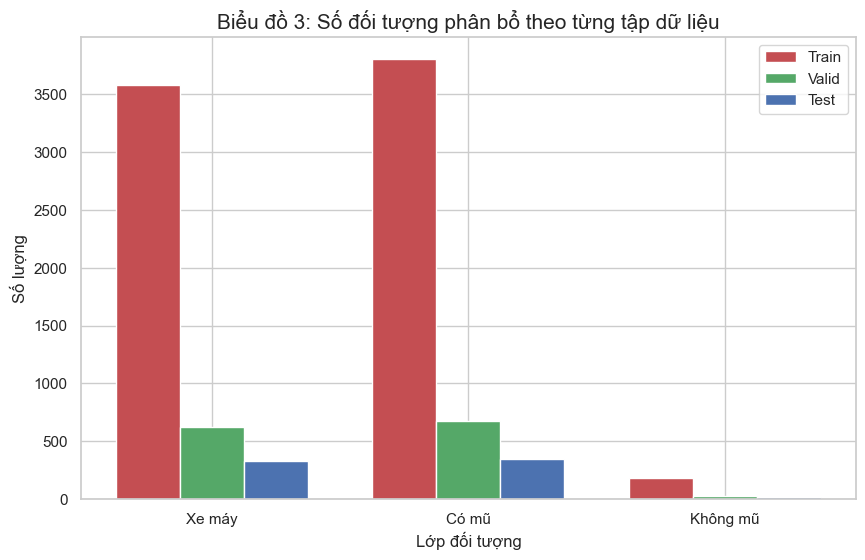

In [43]:
train_vals = [split_counts['train'][i] for i in range(3)]
valid_vals = [split_counts['valid'][i] for i in range(3)]
test_vals = [split_counts['test'][i] for i in range(3)]

X_axis = np.arange(len(names))

plt.figure(figsize=(10, 6))
plt.bar(X_axis - 0.25, train_vals, width=0.25, label='Train', color='r')
plt.bar(X_axis, valid_vals, width=0.25, label='Valid', color='g')
plt.bar(X_axis + 0.25, test_vals, width=0.25, label='Test', color='b')

plt.xticks(X_axis, names)
plt.xlabel("Lớp đối tượng", fontsize=12)
plt.ylabel("Số lượng", fontsize=12)
plt.title("Biểu đồ 3: Số đối tượng phân bổ theo từng tập dữ liệu", fontsize=15)
plt.legend()
plt.show()

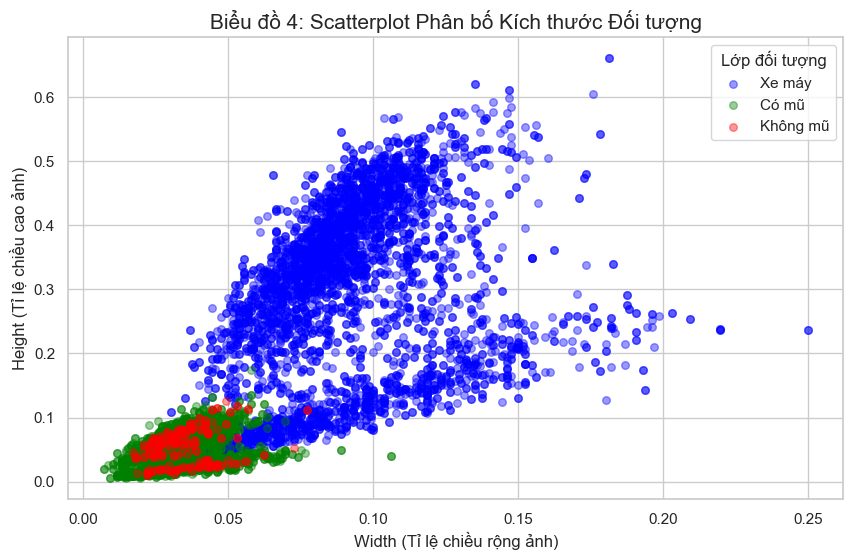

In [44]:
plt.figure(figsize=(10, 6))
colors_map = {0: 'blue', 1: 'green', 2: 'red'}

for cls in [0, 1, 2]:
    subset = df_bbox[df_bbox['Class'] == cls]
    plt.scatter(subset['Width'], subset['Height'],
                c=colors_map[cls], label=class_names_map[cls],
                alpha=0.4, s=30)

plt.title("Biểu đồ 4: Scatterplot Phân bố Kích thước Đối tượng", fontsize=15)
plt.xlabel("Width (Tỉ lệ chiều rộng ảnh)", fontsize=12)
plt.ylabel("Height (Tỉ lệ chiều cao ảnh)", fontsize=12)
plt.legend(title='Lớp đối tượng')
plt.show()

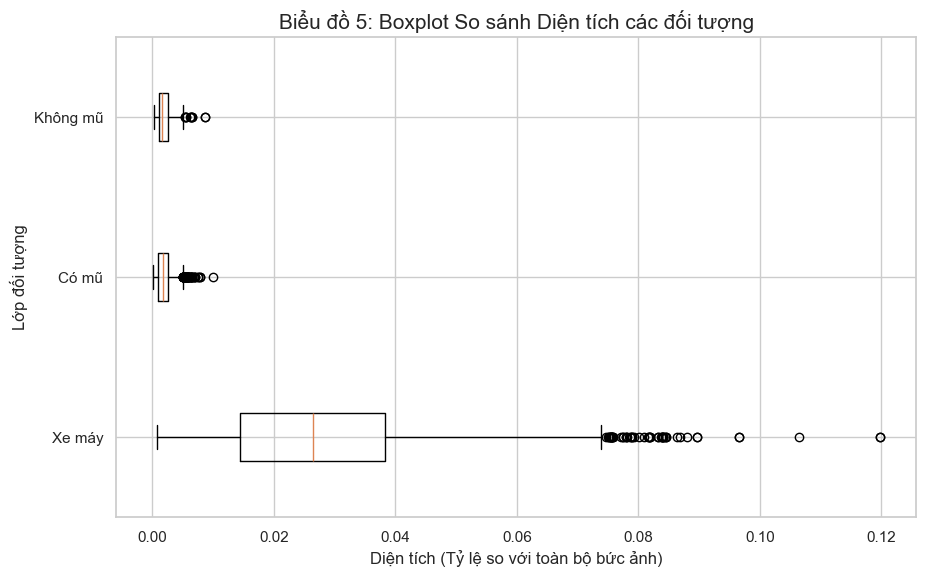

In [45]:
data_boxplot = [
    df_bbox[df_bbox['Class'] == 0]['Area'].values,
    df_bbox[df_bbox['Class'] == 1]['Area'].values,
    df_bbox[df_bbox['Class'] == 2]['Area'].values
]

fig = plt.figure(figsize=(10, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.boxplot(data_boxplot, vert=False)
ax.set_yticklabels(['Xe máy', 'Có mũ', 'Không mũ'])

plt.title("Biểu đồ 5: Boxplot So sánh Diện tích các đối tượng", fontsize=15)
plt.xlabel("Diện tích (Tỷ lệ so với toàn bộ bức ảnh)", fontsize=12)
plt.ylabel("Lớp đối tượng", fontsize=12)
plt.show()

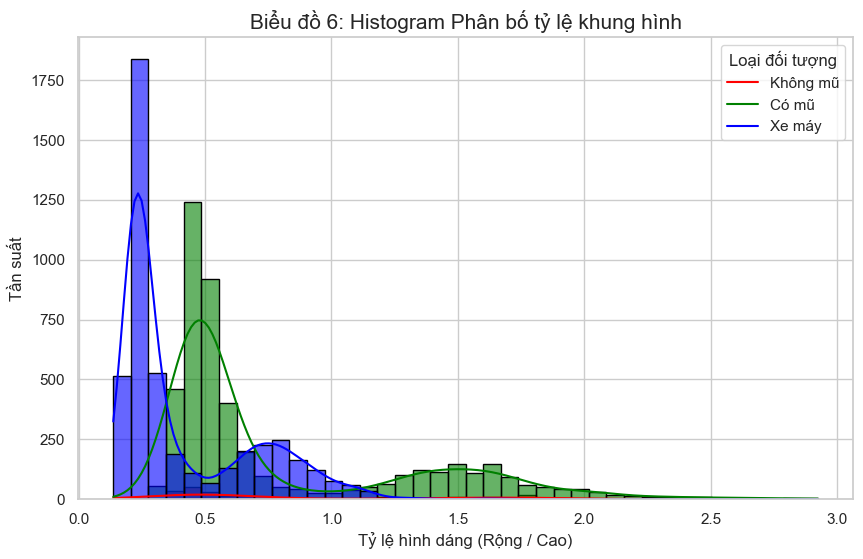

In [46]:
plt.figure(figsize=(10, 6))
du_lieu_da_loc = df_bbox[df_bbox['Aspect_Ratio'] <= 3]

sns.histplot(data=du_lieu_da_loc, x='Aspect_Ratio', hue='Class',
             palette=['blue', 'green', 'red'], bins=40, kde=True,
             edgecolor='black', alpha=0.6)

plt.xlabel('Tỷ lệ hình dáng (Rộng / Cao)', fontsize=12)
plt.ylabel('Tần suất', fontsize=12)
plt.title('Biểu đồ 6: Histogram Phân bố tỷ lệ khung hình', fontsize=15)
plt.legend(title='Loại đối tượng', labels=['Không mũ', 'Có mũ', 'Xe máy'])
plt.show()